# Phase 4 — Instruments, sensors and the flight envelope

The dynamics models have *states* (quaternions, body velocities…). Pilots, autopilots and RL
agents need *instruments*: airspeed, altitude, bank angle, g-load. This phase adds three things:

1. a **common dashboard** that reads the same 28 quantities from either model;
2. **imperfect sensors** (noise and bias), for robustness later;
3. an **envelope monitor** that decides when a flight is lost — which becomes the "episode is
   over" signal of reinforcement learning.

Code: `src/jetsim/aircraft/instruments.py`, `sensors.py`, `envelope.py`.

In [1]:
%matplotlib inline
import math

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

from jetsim.aircraft import dynamics_3dof as d3
from jetsim.aircraft import dynamics_6dof as d6
from jetsim.aircraft import performance as perf
from jetsim.aircraft.envelope import EnvelopeMonitor
from jetsim.aircraft.instruments import INSTRUMENT_NAMES, read_instruments
from jetsim.aircraft.params import SENSORS_DIR, load_aircraft, load_envelope
from jetsim.aircraft.sensors import SensorSuite
from jetsim.core.atmosphere import calibrated_airspeed, equivalent_airspeed, isa_scalar
from jetsim.core.constants import G0
from jetsim.viz.style import INK, INK_2, SERIES, apply_style

apply_style()
plt.rcParams["figure.dpi"] = 110
DEG = math.pi / 180
params = load_aircraft("f16")
six = d6.F16SixDof(params)
three = d3.PointMassAircraft(params)

## 1. One dashboard for both models

`read_instruments(model, x)` returns an `Instruments` record with the same fields whatever the
model. This is what lets the autopilot (notebook 6) and the RL environment ([notebook 7](https://github.com/elouansalaun/jetfighter-rl/blob/main/notebooks/07_gym_environment.ipynb)) work
unchanged on the 3-DOF and the 6-DOF aircraft.

In [2]:
x6, _ = six.trim(3000, 200)
x3, _ = three.trimmed_state(3000, 200)
i6, i3 = read_instruments(six, x6), read_instruments(three, x3)
print(f"{len(INSTRUMENT_NAMES)} instruments: {', '.join(INSTRUMENT_NAMES)}\n")
print(f"{'instrument':<16}{'6-DOF':>10}{'3-DOF':>10}   (trimmed at 3000 m, 200 m/s)")
for name, scale, unit in [
    ("tas", 1, "m/s"),
    ("cas", 1, "m/s"),
    ("mach", 1, ""),
    ("alpha", 1 / DEG, "°"),
    ("pitch", 1 / DEG, "°"),
    ("nz", 1, "g"),
    ("thrust", 1e-3, "kN"),
    ("specific_energy", 1, "m"),
]:
    print(
        f"{name + (f' [{unit}]' if unit else ''):<16}{getattr(i6, name) * scale:>10.2f}"
        f"{getattr(i3, name) * scale:>10.2f}"
    )

28 instruments: north, east, altitude, tas, cas, eas, mach, dynamic_pressure, vertical_speed, gamma, course, bank, roll, pitch, heading, alpha, beta, p, q, r, nx, ny, nz, specific_energy, specific_excess_power, airspeed_rate, thrust, power

instrument           6-DOF     3-DOF   (trimmed at 3000 m, 200 m/s)
tas [m/s]           200.00    200.00
cas [m/s]           174.59    174.59
mach                  0.61      0.61
alpha [°]             1.48      1.23
pitch [°]             1.48      1.23
nz [g]                1.00      1.00
thrust [kN]          11.80     11.01
specific_energy [m]   5039.43   5039.43


The two models agree on the trim angle of attack to within a degree — a useful cross-check,
since one uses a fitted drag polar and the other the NASA tables. (The point-mass model has no
body attitude of its own: its pitch angle is reconstructed from the wind frame and α.)

## 2. Which airspeed?

There are several "airspeeds", and they differ a lot at altitude:

* **TAS** (true airspeed) — the actual speed through the air, used by the physics;
* **EAS** (equivalent airspeed) $= V\sqrt{\rho/\rho_0}$ — gives the same dynamic pressure at
  sea level, i.e. the same aerodynamic forces;
* **CAS** (calibrated airspeed) — what a pitot tube and cockpit gauge show, from the impact
  pressure $q_c = P\,[(1 + 0.2M^2)^{3.5} - 1]$ (Rayleigh's formula above Mach 1).

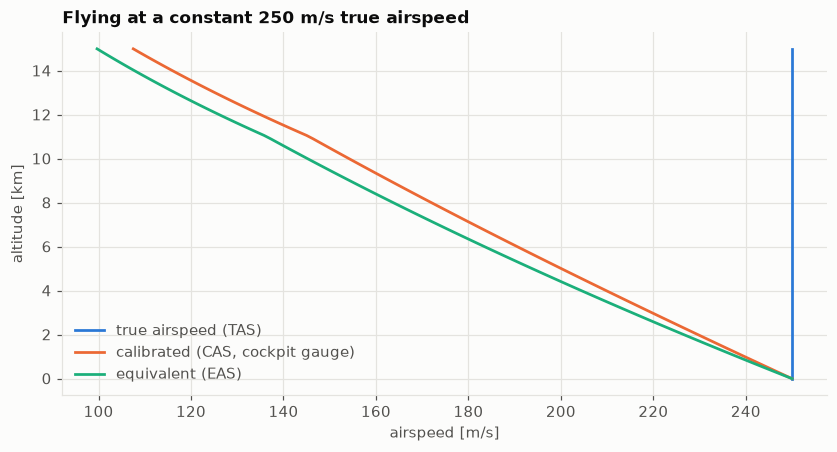

In [3]:
alts = np.linspace(0, 15_000, 100)
V = 250.0
fig, ax = plt.subplots(figsize=(7.5, 4), layout="constrained")
ax.plot(np.full_like(alts, V), alts / 1000, color=SERIES[0], label="true airspeed (TAS)")
ax.plot(
    [calibrated_airspeed(V, h) for h in alts],
    alts / 1000,
    color=SERIES[1],
    label="calibrated (CAS, cockpit gauge)",
)
ax.plot(
    [equivalent_airspeed(V, h) for h in alts],
    alts / 1000,
    color=SERIES[2],
    label="equivalent (EAS)",
)
ax.set_xlabel("airspeed [m/s]"), ax.set_ylabel("altitude [km]")
ax.set_title("Flying at a constant 250 m/s true airspeed")
ax.legend(loc="lower left")
plt.show()

At 12 km, a gauge reading ~145 m/s means the aircraft is actually doing 250 m/s. Since the
aircraft "feels" CAS/EAS (forces, stall), speed limits and many control laws are expressed in
those terms.

## 3. Bank angle μ versus roll angle φ

Two angles are casually called "bank":

* **roll φ** — rotation of the *fuselage* (body frame, Euler angle);
* **bank μ** — rotation of the *lift vector* around the velocity.

In a level turn, it is μ that must satisfy $n\cos\mu = 1$. At small angle of attack they are
the same; at high angle of attack they are not, because the fuselage is pitched up relative to
the velocity. Using φ instead of μ made the autopilot's tight turns fail (notebook 6) —
which is why `bank` was added to the dashboard.

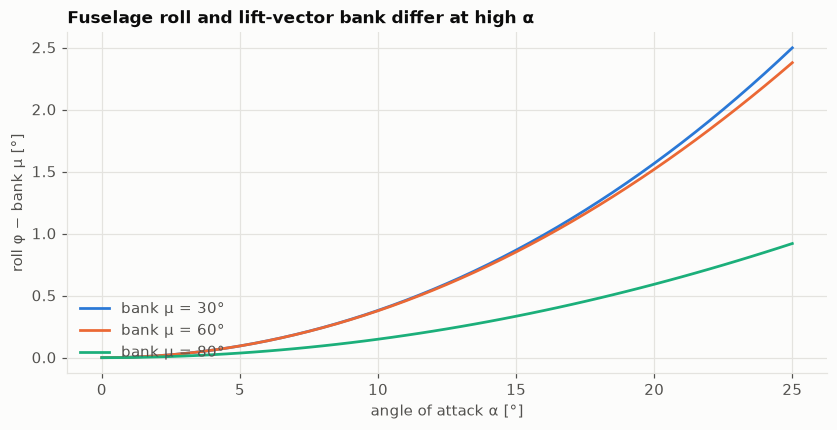

In [4]:
alphas = np.linspace(0, 25, 51)
fig, ax = plt.subplots(figsize=(7.5, 3.8), layout="constrained")
for bank, color in zip((30, 60, 80), SERIES, strict=True):
    rolls = []
    for a in alphas:
        x = three.make_state(altitude=5000, airspeed=200, bank=bank * DEG, alpha=a * DEG)
        rolls.append(read_instruments(three, x).roll / DEG)
    ax.plot(alphas, np.array(rolls) - bank, color=color, label=f"bank μ = {bank}°")
ax.set_xlabel("angle of attack α [°]"), ax.set_ylabel("roll φ − bank μ [°]")
ax.set_title("Fuselage roll and lift-vector bank differ at high α")
ax.legend(loc="lower left")
plt.show()

A few degrees may look harmless, but in a tight turn the vertical component of lift is
$n\,W\cos\mu$: at 80° of bank, a 1° error on μ changes it by about 10 %, enough to make the
aircraft climb or sink steadily.

## 4. Energy: the currency of air combat

Fighter pilots think in **energy**. The *specific energy* (energy per unit weight, in meters)
and its rate of change, the *specific excess power*, are

$$E_s = h + \frac{V^2}{2g}, \qquad P_s = \frac{dE_s}{dt} = \frac{V\,(T - D)}{W}$$

$P_s > 0$ means the aircraft can climb or accelerate; $P_s < 0$ means it is bleeding energy.
Mapping $P_s$ over altitude and Mach gives the classic **energy-maneuverability diagram**
(John Boyd, 1960s). This is exactly the quantity a missile-evading agent will have to manage
in phase 10: a missile is fast but its motor burns out, and the fight becomes an energy contest.

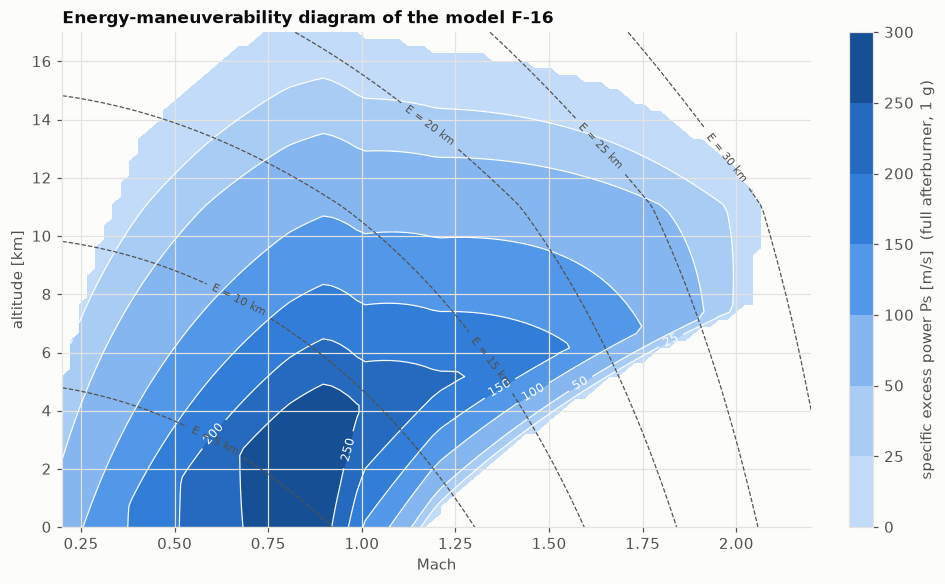

In [5]:
machs = np.linspace(0.2, 2.2, 90)
heights = np.linspace(0, 17_000, 70)
ps = np.full((heights.size, machs.size), np.nan)
for i, h in enumerate(heights):
    a = perf.speed_of_sound(float(h))
    for j, m in enumerate(machs):
        value = perf.excess_power(three, float(h), float(m * a))
        ps[i, j] = value if math.isfinite(value) else np.nan
ps_pos = np.where(ps >= 0, ps, np.nan)

blues = LinearSegmentedColormap.from_list(
    "blue_ramp", ["#cde2fb", "#86b6ef", "#3987e5", "#256abf", "#104281"]
)
fig, ax = plt.subplots(figsize=(8.5, 5.2), layout="constrained")
levels = [0, 25, 50, 100, 150, 200, 250, 300]
cf = ax.contourf(machs, heights / 1000, ps_pos, levels=levels, cmap=blues)
cs = ax.contour(machs, heights / 1000, ps_pos, levels=levels[1:], colors="white", linewidths=0.8)
ax.clabel(cs, fmt="%d", fontsize=8)
# lines of constant specific energy
M, Hm = np.meshgrid(machs, heights)
sound = np.vectorize(lambda h: isa_scalar(h)[3])(Hm)
energy = Hm + (M * sound) ** 2 / (2 * G0)
ce = ax.contour(
    machs,
    heights / 1000,
    energy / 1000,
    levels=[5, 10, 15, 20, 25, 30],
    colors=INK_2,
    linewidths=0.8,
    linestyles="dashed",
)
ax.clabel(ce, fmt="E = %d km", fontsize=7.5)
fig.colorbar(cf, ax=ax, label="specific excess power Ps [m/s]  (full afterburner, 1 g)")
ax.set_xlabel("Mach"), ax.set_ylabel("altitude [km]")
ax.set_title("Energy-maneuverability diagram of the model F-16")
plt.show()

Colored area = where the aircraft can gain energy; dashed lines = constant total energy. The
fastest way to gain energy follows the darkest region; a zoom climb trades speed for altitude
along a dashed line.

## 5. Imperfect sensors

A policy trained on perfect measurements can be fragile. `SensorSuite` adds, per channel:

* white **noise** $\sim \mathcal N(0, \sigma^2)$ at every reading;
* a constant **bias** drawn once per episode (imperfect calibration, different every flight).

Sensors are perfect by default; `src/jetsim/data/sensors/realistic.yaml` holds typical air-data and
inertial-unit values. The RL environment computes observations from the *measured* values but
rewards and crashes from the *true* ones.

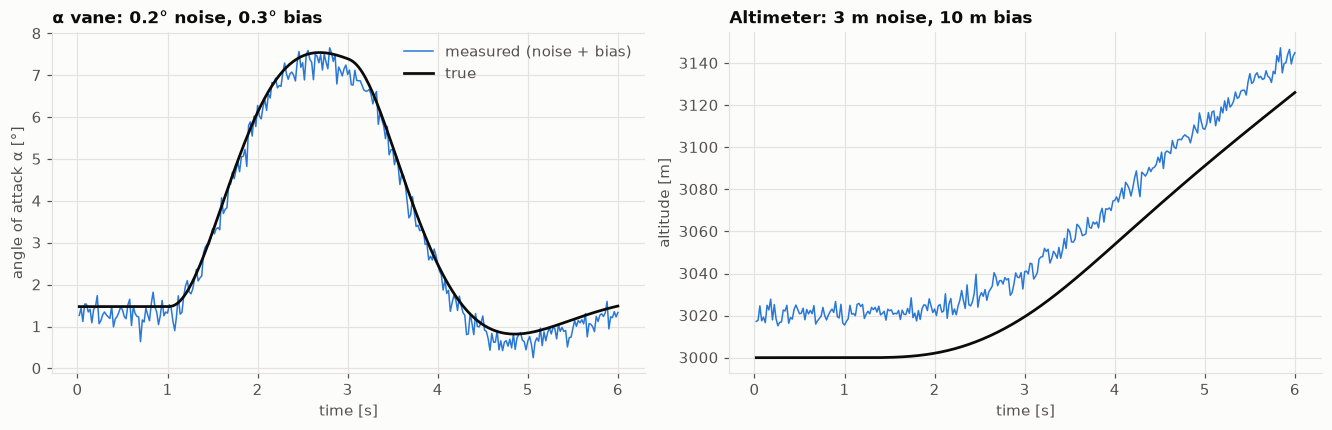

biases drawn for this episode: {'altitude': 20.41, 'alpha': -0.17, 'nz': -0.0}


In [6]:
sensors = SensorSuite.from_yaml(SENSORS_DIR / "realistic.yaml", np.random.default_rng(3))
x, u = six.trim(3000, 200)
u_pull = u.copy()
u_pull[d6.ELEVATOR] -= 2 * DEG  # a gentle pull-up
t_hist, true_alpha, meas_alpha, true_h, meas_h = [], [], [], [], []
for k in range(300):
    for _ in range(2):
        x = six.step(x, u_pull if 50 <= k < 150 else u)
    truth = read_instruments(six, x)
    meas = sensors.measure(truth)
    t_hist.append((k + 1) * 0.02)
    true_alpha.append(truth.alpha / DEG), meas_alpha.append(meas.alpha / DEG)
    true_h.append(truth.altitude), meas_h.append(meas.altitude)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), layout="constrained")
for ax, meas_v, true_v, label in (
    (axes[0], meas_alpha, true_alpha, "angle of attack α [°]"),
    (axes[1], meas_h, true_h, "altitude [m]"),
):
    ax.plot(t_hist, meas_v, color=SERIES[0], linewidth=1.0, label="measured (noise + bias)")
    ax.plot(t_hist, true_v, color=INK, linewidth=1.8, label="true")
    ax.set_xlabel("time [s]"), ax.set_ylabel(label)
axes[0].set_title("α vane: 0.2° noise, 0.3° bias")
axes[1].set_title("Altimeter: 3 m noise, 10 m bias")
axes[0].legend(loc="upper right")
plt.show()
print(
    "biases drawn for this episode:",
    {
        k: round(v / DEG, 2) if k in ("alpha", "beta") else round(v, 2)
        for k, v in sensors.bias.items()
        if k in ("alpha", "altitude", "nz")
    },
)

## 6. The flight envelope: when is a flight lost?

For learning, the simulator must say clearly when an episode ends in failure. The
`EnvelopeMonitor` checks, in priority order:

| Violation | Condition (F-16 config) |
|---|---|
| numerical divergence | any NaN/inf in the state |
| ground collision | altitude < 0 |
| structural overload | $n_z \notin [-4, +10]$ g |
| ceiling | altitude > 17 km |
| too slow | TAS < 50 m/s |
| overspeed | Mach > 2.0 (0.95 for the 6-DOF, the limit of its tables) |
| sideslip | $|\beta| > 30°$ (limit of the tables) |
| prolonged stall | α > 30° **for more than 2 s** |

The stall check has memory: a brief excursion past 30° is a maneuver, not a loss of control.

**Demo:** from level flight at 3000 m, pull up, roll inverted, then pull into a dive at full
throttle *without pulling hard enough* — a botched Split-S. The monitor stops the flight.

flight ended at t = 17.8 s — violation: OVERSPEED (Mach 0.951, altitude 1860 m)


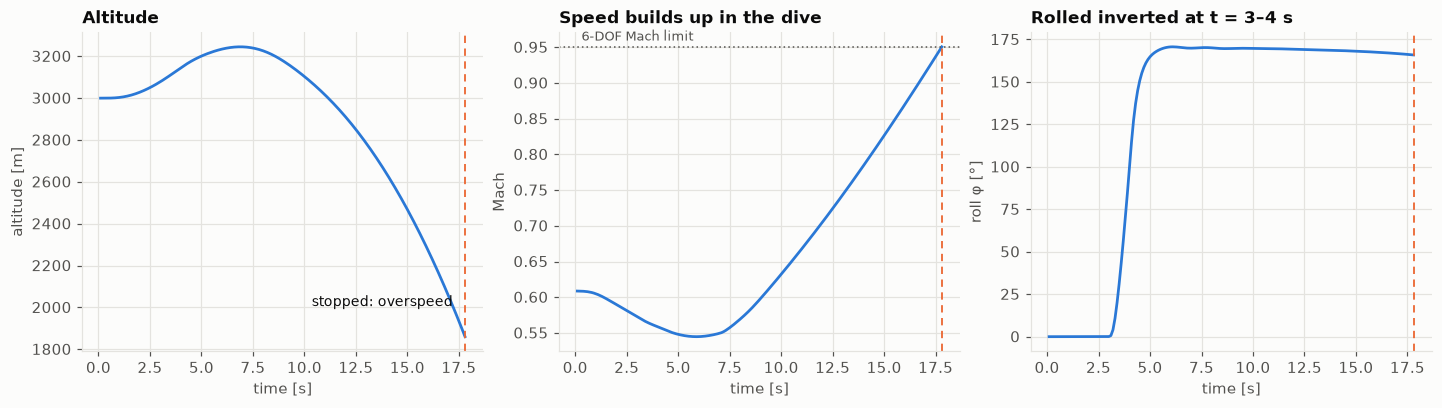

In [7]:
monitor = EnvelopeMonitor(load_envelope("f16", six_dof=True))
x, u_trim = six.trim(3000.0, 200.0)


def botched_split_s(t):
    u = u_trim.copy()
    if t < 3.0:
        u[d6.ELEVATOR] -= 3 * DEG  # pull up
    elif t < 4.0:
        u[d6.AILERON] = -12 * DEG  # half roll to inverted
    elif t >= 5.0:
        u[d6.ELEVATOR] -= 2 * DEG if t < 8.0 else 0.0  # pull, but not enough
        u[d6.THROTTLE] = 1.0
    return u


t, violation, log = 0.0, None, []
while violation is None and t < 60.0:
    u = botched_split_s(t)
    for _ in range(10):
        x = six.step(x, u)
    t += 0.1
    ins = read_instruments(six, x)
    violation = monitor.check(ins, 0.1, state=x)
    log.append((t, ins.altitude, ins.mach, ins.roll / DEG, ins.nz))
log = np.array(log)
print(
    f"flight ended at t = {t:.1f} s — violation: {violation.name} "
    f"(Mach {log[-1, 2]:.3f}, altitude {log[-1, 1]:.0f} m)"
)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), layout="constrained")
for ax, col, label in (
    (axes[0], 1, "altitude [m]"),
    (axes[1], 2, "Mach"),
    (axes[2], 3, "roll φ [°]"),
):
    ax.plot(log[:, 0], log[:, col], color=SERIES[0])
    ax.axvline(t, color=SERIES[1], linewidth=1.2, linestyle=(0, (4, 3)))
    ax.set_xlabel("time [s]"), ax.set_ylabel(label)
axes[1].axhline(0.95, color=INK_2, linewidth=1, linestyle=(0, (1, 2)))
axes[1].text(0.3, 0.955, "6-DOF Mach limit", color=INK_2, fontsize=8.5, va="bottom")
axes[0].set_title("Altitude")
axes[1].set_title("Speed builds up in the dive")
axes[2].set_title("Rolled inverted at t = 3–4 s")
axes[0].annotate(
    f"stopped: {violation.name.lower()}",
    (t, log[-1, 1]),
    xytext=(-8, 20),
    textcoords="offset points",
    ha="right",
    color=INK,
    fontsize=9,
)
plt.show()

The dive accelerates past the 6-DOF model's validity limit (Mach 0.95) before reaching the
ground, so the flight is stopped for **overspeed** — the aircraft was lost either way.

In RL terms this is a `terminated = True` step with a large penalty ([notebook 7](https://github.com/elouansalaun/jetfighter-rl/blob/main/notebooks/07_gym_environment.ipynb)). Priorities
matter: when several limits are crossed at once, the most fundamental one is reported.

## Takeaways

* A **single dashboard** hides the model's internals from everything above it — the key to
  developing on the fast 3-DOF and transferring to the 6-DOF.
* Getting the "obvious" quantities right (CAS vs TAS, bank μ vs roll φ) prevents subtle
  control failures later.
* **Energy** ($E_s$, $P_s$) is computed from the start, anticipating the missile-evasion phase.
* The **envelope monitor** turns "the aircraft is in trouble" into a precise, logged
  termination signal — the basis of every RL episode.

**Next:** notebook 5 records, replays and visualizes flights.